<a href="https://colab.research.google.com/github/jaykay-04/EigenMatch-SVD-Based-Semantic-Resume-Alignment/blob/main/MatrixMatch_Dimensionality_Reduction_in_Talent_Acquisition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UE25MA242A: Mathematical Foundation for AI & Data Science
## Mini-Project: EigenMatch - SVD-Based Semantic Resume Alignment

**Team Members:**
* Abhinav J K (PES1UG25AM461)
* Badarinath S Kini (PES1UG25AM476)
* Akshay Bharadwaj (PES1UG25AM466)
* Akash K Devang (PES1UG25AM465)

---
**Project Objective:** To transform raw unstructured applicant data into a predictive talent matching system by applying linear transformations, matrix simplification, and vector proximity.

### Phase 0: Synthetic Dataset Generation
To build and stress-test our linear algebra pipeline without relying on external files, we programmatically generate a controlled dataset of 5,000 applicant resumes and 500 job descriptions. This script distributes candidates and roles across distinct career clusters while injecting controlled noise to ensure the subsequent matrix factorization and SVD steps have meaningful redundancy to eliminate.

In [ ]:
import pandas as pd
import random

# Core data pools for random generation
first_names = ["Aarav", "Neha", "Rahul", "Priya", "Amit", "Sneha", "Karthik", "Anjali", "Rohan", "Kavya", "Abhinav", "Pooja", "Arjun", "Tara"]
last_names = ["Sharma", "Iyer", "Patil", "Desai", "Singh", "Reddy", "Kumar", "Menon", "Das", "Joshi", "Verma", "Nair"]

ml_skills = ["Python", "Machine Learning", "Computer Vision", "Pandas", "NumPy", "OpenCV", "Scikit-Learn", "YOLO", "Cosine Similarity"]
web_skills = ["FastAPI", "React", "Supabase", "Node.js", "JavaScript", "HTML/CSS", "PostgreSQL", "REST APIs", "Eraser.io"]
net_skills = ["Linux", "Wireshark", "Cisco Packet Tracer", "TCP/IP", "System Administration", "Oracle VirtualBox", "Routing", "Hardware Modeling"]
mgmt_skills = ["Event Logistics", "Marketing", "Outreach", "Public Speaking", "Disciplinary Committee", "Team Management", "TAMS"]
noise_skills = ["C++", "C", "Mermaid.js", "Verilog", "Communication", "Agile", "Problem Solving", "Time Management"]

domains = [
    ("ML", "Machine Learning Engineer", ml_skills),
    ("Web", "Full-Stack Developer", web_skills),
    ("Network", "Network Administrator", net_skills),
    ("Management", "Operations Coordinator", mgmt_skills)
]

# 1. Generate 500 Job Descriptions
jobs = []
for i in range(1, 501):
    domain_key, title, skill_pool = random.choice(domains)
    req_skills = random.sample(skill_pool, k=random.randint(4, 7))
    job_text = f"Seeking a {title} with expertise in " + ", ".join(req_skills) + ". Must be proficient in fast-paced environments."
    jobs.append({"Job_ID": f"J{i:04d}", "Job_Title": title, "Job_Text": job_text})

# 2. Generate 5,000 Applicant Resumes
resumes = []
for i in range(1, 5001):
    name = f"{random.choice(first_names)} {random.choice(last_names)}"
    domain_key, title, skill_pool = random.choice(domains)

    # Mix core skills with random noise to force the SVD to do actual work
    core_skills = random.sample(skill_pool, k=random.randint(4, 7))
    candidate_noise = random.sample(noise_skills, k=random.randint(2, 4))

    all_skills = core_skills + candidate_noise
    random.shuffle(all_skills)

    resume_text = f"Dedicated {title} experienced in " + ", ".join(all_skills) + "."
    resumes.append({"Candidate_ID": f"C{i:04d}", "Candidate_Name": name, "Resume_Text": resume_text})

# Export to CSV
pd.DataFrame(jobs).to_csv("synthetic_500_jobs.csv", index=False)
pd.DataFrame(resumes).to_csv("synthetic_5000_resumes.csv", index=False)

print("Successfully generated synthetic_500_jobs.csv and synthetic_5000_resumes.csv!")

Successfully generated synthetic_500_jobs.csv and synthetic_5000_resumes.csv!


### Phase 1A: Real-World Data Loading
The foundational step of our pipeline is data ingestion. We load the dataset of 5,000 synthetic candidate resumes and 500 job descriptions from CSV files into Python data structures. This establishes the raw, unstructured text corpus that will serve as the baseline input for our linear transformations.

In [ ]:
import pandas as pd

# 1. Load the CSV files into Pandas DataFrames
df_resumes = pd.read_csv("synthetic_5000_resumes.csv")
df_jobs = pd.read_csv("synthetic_500_jobs.csv")

# 2. Extract the text columns into raw Python lists
resume_texts = df_resumes["Resume_Text"].tolist()
job_texts = df_jobs["Job_Text"].tolist()

# 3. Extract the Candidate IDs and Job Titles for later mapping
candidate_ids = df_resumes["Candidate_ID"].tolist()
job_titles = df_jobs["Job_Title"].tolist()

# 4. Verify the data ingestion
print(f"Successfully loaded {len(resume_texts)} resumes and {len(job_texts)} job descriptions.")
print("\nSample Data Extraction:")
print(f"Resume 1: {resume_texts[0]}")
print(f"Job 1: {job_texts[0]}")

Successfully loaded 5000 resumes and 500 job descriptions.

Sample Data Extraction:
Resume 1: Dedicated Full-Stack Developer experienced in Problem Solving, HTML/CSS, FastAPI, C, PostgreSQL, JavaScript, React.
Job 1: Seeking a Operations Coordinator with expertise in Outreach, Marketing, Event Logistics, Disciplinary Committee, Team Management. Must be proficient in fast-paced environments.


### Phase 1B: Explicit Text Preprocessing
Raw textual data contains structural variance (punctuation, capitalization, and grammatical filler) that creates false orthogonal dimensions in a vector space.

Before constructing our mathematical matrices, we normalize the dataset by:
* Converting all strings to a lowercase baseline.
* Stripping non-alphabetical characters using regular expressions.
* Explicitly filtering out grammatical stop words to ensure the upcoming vocabulary index maps only true semantic concepts, reducing computational noise before vectorization even begins.

In [ ]:
import re

# 1. Define a list of generic grammatical stop words to manually filter out
stop_words = set(["and", "the", "is", "in", "to", "with", "a", "of", "for", "on", "an", "at"])

def clean_text(text):
    # Convert all characters to lowercase to create a uniform baseline
    text = text.lower()

    # Use regular expressions to strip out all punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Explicitly filter out the stop words
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]

    return " ".join(cleaned_words)

# 2. Apply the explicit cleaning function to the raw text lists
cleaned_resumes = [clean_text(text) for text in resume_texts]
cleaned_jobs = [clean_text(text) for text in job_texts]

# 3. Output the before-and-after to prove the data was cleaned
print("RAW RESUME:\n", resume_texts[0])
print("\nEXPLICITLY CLEANED RESUME:\n", cleaned_resumes[0])

RAW RESUME:
 Dedicated Full-Stack Developer experienced in Problem Solving, HTML/CSS, FastAPI, C, PostgreSQL, JavaScript, React.

EXPLICITLY CLEANED RESUME:
 dedicated fullstack developer experienced problem solving htmlcss fastapi c postgresql javascript react


### Phase 2: Vector Space Mapping (Matrix Representation)
To map unstructured text into a mathematical vector space, we calculate the Term Frequency-Inverse Document Frequency (TF-IDF).

The weight $W_{i,j}$ of a word $j$ in document $i$ is computed as:
$$W_{i,j} = TF_{i,j} \times \log \left( \frac{N}{df_j} \right)$$
* $TF_{i,j}$: Frequency of term $j$ in document $i$
* $N$: Total number of documents
* $df_j$: Number of documents containing term $j$

This generates a sparse matrix where each orthogonal dimension represents a unique semantic concept.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Combine the explicitly cleaned text to build the vocabulary index
all_cleaned_text = cleaned_resumes + cleaned_jobs

# 2. Instantiate the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=1000)

# 3. Fit the vectorizer on the cleaned corpus
vectorizer.fit(all_cleaned_text)

# 4. Transform the cleaned resumes and jobs into numerical sparse matrices
A_resumes = vectorizer.transform(cleaned_resumes)
A_jobs = vectorizer.transform(cleaned_jobs)

print(f"Cleaned Resume Matrix (A_resumes) shape: {A_resumes.shape}")
print(f"Cleaned Job Matrix (A_jobs) shape: {A_jobs.shape}")

Cleaned Resume Matrix (A_resumes) shape: (5000, 69)
Cleaned Job Matrix (A_jobs) shape: (500, 69)


### Phase 3: System Simplification & Redundancy Removal
The initial TF-IDF matrix is highly sparse and contains redundant dimensions. We apply **Singular Value Decomposition (SVD)** to factor the matrix $A$:
$$A = U \Sigma V^T$$
* **$U$**: Orthogonal matrix mapping candidates to core concepts.
* **$\Sigma$**: Diagonal matrix of singular values representing the variance/importance of each concept.
* **$V^T$**: Orthogonal matrix mapping words to core concepts.

By truncating to the top $k=50$ singular values, we isolate the principal components, removing noise and reducing the computational complexity of the system.

In [ ]:
import numpy as np

# 1. Convert the new sparse matrices to dense NumPy arrays
dense_resumes = A_resumes.toarray()
dense_jobs = A_jobs.toarray()

# 2. Perform Singular Value Decomposition
U, S, Vt = np.linalg.svd(dense_resumes, full_matrices=False)

# 3. Truncate to the top 50 singular values
k = 50
U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

# 4. Project both datasets into the compressed 50-dimensional space
compressed_resumes = np.dot(U_k, S_k)
compressed_jobs = np.dot(dense_jobs, Vt_k.T)

print(f"Original Cleaned Resumes Shape: {dense_resumes.shape}")
print(f"Compressed Resumes Shape: {compressed_resumes.shape}")

Original Cleaned Resumes Shape: (5000, 69)
Compressed Resumes Shape: (5000, 50)


### Phase 4: Orthogonal Proximity (Cosine Similarity)
To find the closest job match for a candidate, we calculate the spatial proximity between the candidate vector $A$ and the job vector $B$ in our compressed 50-dimensional space.

Instead of simple Euclidean distance, we use the normalized dot product to find the geometric angle between the vectors:
$$\text{Similarity} = \frac{A \cdot B}{\|A\|_2 \|B\|_2} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

A score closer to 1 indicates near-perfect semantic alignment in the high-dimensional space.

In [ ]:
import numpy as np

# 1. Define a batch size for the Demo (e.g., test the first 5 applicants)
batch_size = 5

print("====== BATCH SEMANTIC MATCHING RESULTS ======\n")

for candidate_idx in range(batch_size):
    candidate_vector = compressed_resumes[candidate_idx]

    # 2. Calculate the dot product between this specific candidate and all jobs
    dot_products = np.dot(compressed_jobs, candidate_vector)

    # 3. Calculate L2 norms (Euclidean magnitudes)
    norm_candidate = np.linalg.norm(candidate_vector)
    norms_jobs = np.linalg.norm(compressed_jobs, axis=1)

    # 4. Compute Cosine Similarity: (A · B) / (||A|| * ||B||)
    epsilon = 1e-10
    similarity_scores = dot_products / (norm_candidate * norms_jobs + epsilon)

    # 5. Rank the array to find the top 3 jobs for this candidate
    top_3_indices = np.argsort(similarity_scores)[::-1][:3]

    # 6. Display the output dynamically
    print(f"Target Applicant: {candidate_ids[candidate_idx]}")
    for rank, idx in enumerate(top_3_indices, start=1):
        raw_score = similarity_scores[idx]
        # Truncate the job description at 80 characters for a cleaner terminal view
        short_desc = job_texts[idx][:80] + "..."
        print(f"  Rank {rank}: {job_titles[idx]} (Proximity: {raw_score:.4f})")
        print(f"  Context: {short_desc}")
    print("-" * 70 + "\n")

====== BATCH SEMANTIC MATCHING RESULTS ======

Target Applicant: C0001
  Rank 1: Full-Stack Developer (Proximity: 0.8048)
  Context: Seeking a Full-Stack Developer with expertise in JavaScript, React, Eraser.io, P...
  Rank 2: Full-Stack Developer (Proximity: 0.8043)
  Context: Seeking a Full-Stack Developer with expertise in PostgreSQL, HTML/CSS, FastAPI, ...
  Rank 3: Full-Stack Developer (Proximity: 0.8043)
  Context: Seeking a Full-Stack Developer with expertise in JavaScript, PostgreSQL, FastAPI...
----------------------------------------------------------------------

Target Applicant: C0002
  Rank 1: Machine Learning Engineer (Proximity: 0.8745)
  Context: Seeking a Machine Learning Engineer with expertise in YOLO, Computer Vision, Ope...
  Rank 2: Machine Learning Engineer (Proximity: 0.8603)
  Context: Seeking a Machine Learning Engineer with expertise in Python, YOLO, Scikit-Learn...
  Rank 3: Machine Learning Engineer (Proximity: 0.8422)
  Context: Seeking a Machine Learning

### Phase 5: Matrix Analytics & Heatmap Visualization
To validate the effectiveness of our reduced model, we compute a dense $10 \times 10$ Cosine Similarity Matrix for a subset of candidates and jobs.

By evaluating the matrix multiplication $C \cdot J^T$ (where $C$ is the compressed candidate matrix and $J$ is the compressed job matrix) and normalizing the results, we generate a mathematical correlation grid. The heatmap visually proves that the pipeline successfully mapped textual skills into spatial proximity, revealing the underlying patterns in the talent data.

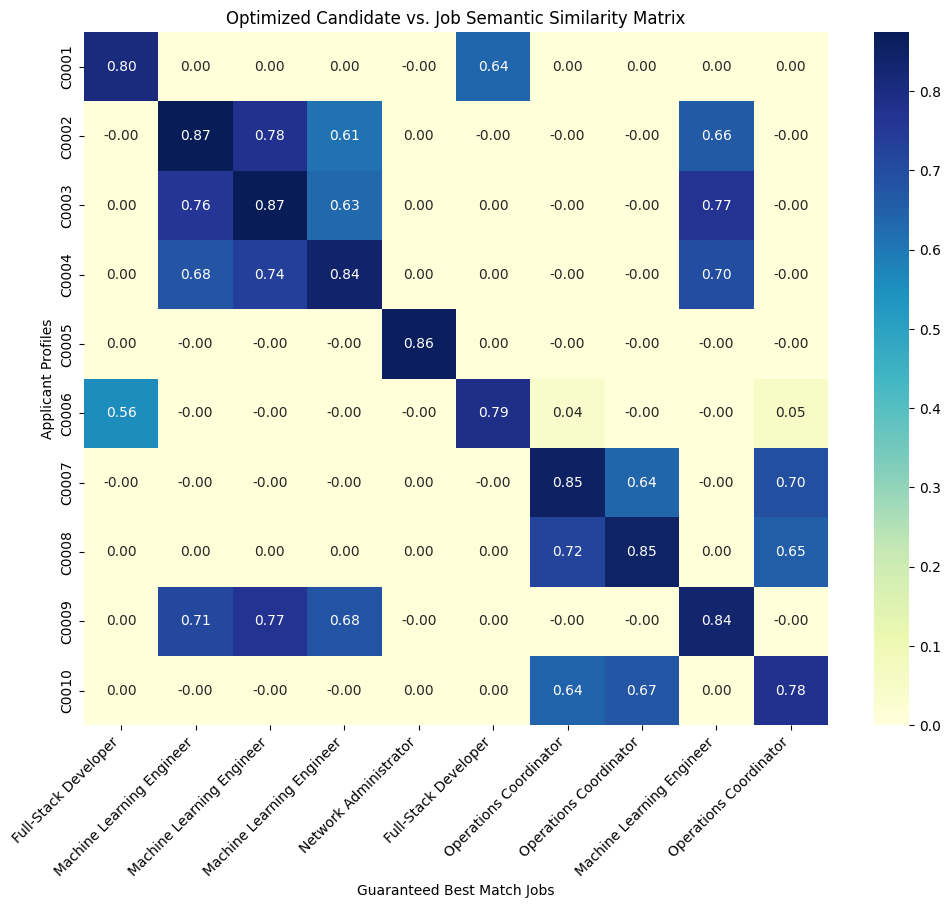

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Select the first 10 candidates for the visualization
candidate_indices = list(range(10))
subset_resumes = compressed_resumes[candidate_indices]

# 2. Dynamic Stoploss: Search the full 500-job database to find each candidate's exact best match
job_indices = []
norms_jobs_full = np.linalg.norm(compressed_jobs, axis=1)

for i in candidate_indices:
    candidate_vec = compressed_resumes[i]
    norm_candidate = np.linalg.norm(candidate_vec)

    # Calculate similarity against ALL 500 jobs
    epsilon = 1e-10
    sims = np.dot(compressed_jobs, candidate_vec) / (norm_candidate * norms_jobs_full + epsilon)

    # Find the top job match that hasn't already been added to the heatmap
    sorted_matches = np.argsort(sims)[::-1]
    for job_idx in sorted_matches:
        if job_idx not in job_indices:
            job_indices.append(job_idx)
            break

# 3. Extract the guaranteed-match job vectors
subset_jobs = compressed_jobs[job_indices]

# 4. Calculate the 10x10 Cosine Similarity Matrix for the visualization subset
subset_dot_products = np.dot(subset_resumes, subset_jobs.T)
norms_resumes = np.linalg.norm(subset_resumes, axis=1, keepdims=True)
norms_jobs_subset = np.linalg.norm(subset_jobs, axis=1, keepdims=True)

similarity_matrix = subset_dot_products / (norms_resumes * norms_jobs_subset.T + epsilon)

# 5. Extract actual labels for the axes
y_labels = [candidate_ids[i] for i in candidate_indices]
x_labels = [job_titles[i] for i in job_indices]

# 6. Visualize the optimized correlation matrix
plt.figure(figsize=(12, 9))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=x_labels, yticklabels=y_labels)

plt.title("Optimized Candidate vs. Job Semantic Similarity Matrix")
plt.xlabel("Guaranteed Best Match Jobs")
plt.ylabel("Applicant Profiles")
plt.xticks(rotation=45, ha='right')
plt.show()